In [1]:
import os
import copy
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from preprocess_roi import preprocess_roi_from_uint16png

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, image_size=128, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.image_size = image_size
        self.augment = augment

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        img = preprocess_roi_from_uint16png(img, size=self.image_size)

        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()

            if np.random.rand() < 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D(
                    (self.image_size//2, self.image_size//2), angle, 1.0
                )
                img = cv2.warpAffine(
                    img, M, (self.image_size, self.image_size),
                    borderMode=cv2.BORDER_REFLECT
                )

            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0, 1)

        img = img.astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0).repeat(3,1,1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)
        return img, label

In [4]:
train_dir = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\test"

IMG_SIZE = 128        
BATCH_SIZE = 32        

NUM_WORKERS = 0

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [5]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

train_paths = [s[0] for s in train_base.samples]
train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['benign', 'malignant']
Train: 7758
Val: 940
Test: 853


In [6]:
train_data = CTDataset(train_paths, train_labels, image_size=IMG_SIZE, augment=True)
val_data   = CTDataset(val_paths, val_labels, image_size=IMG_SIZE, augment=False)
test_data  = CTDataset(test_paths, test_labels, image_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [7]:
dropout_rate = 0.6

model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [9]:
def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {}
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["f1"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    if y_prob is not None:
        try:
            if num_classes == 2:
                metrics["auc"] = roc_auc_score(y_true, y_prob[:, 1])
            else:
                metrics["auc"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    return metrics

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(y_true, y_pred, np.array(y_prob))
    return avg_loss, metrics

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    y_prob = np.array(y_prob)
    metrics = compute_metrics(y_true, y_pred, y_prob)

    return avg_loss, metrics, y_true, y_pred, y_prob

In [12]:
learning_rate = 1e-3
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

In [13]:
history = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_auc": [],
    "val_auc": [],
    "epoch_time_sec": []
}

best_auc = 0
best_wts = copy.deepcopy(model.state_dict())

In [14]:
freeze_epochs = 5

for epoch in range(freeze_epochs):
    start = time.time()

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    epoch_time = time.time() - start

    history["phase"].append("frozen")
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"[Frozen] Epoch {epoch+1}/{freeze_epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        best_wts = copy.deepcopy(model.state_dict())

[Frozen] Epoch 1/5 | Train Loss: 0.6344 | Val Loss: 0.6100 | Train Acc: 0.6520 | Val Acc: 0.6574 | Val F1: 0.6403 | Val AUC: 0.6645 | Time: 41.7s
[Frozen] Epoch 2/5 | Train Loss: 0.6122 | Val Loss: 0.6084 | Train Acc: 0.6732 | Val Acc: 0.6617 | Val F1: 0.6585 | Val AUC: 0.6912 | Time: 42.9s
[Frozen] Epoch 3/5 | Train Loss: 0.5946 | Val Loss: 0.5920 | Train Acc: 0.6877 | Val Acc: 0.6766 | Val F1: 0.6609 | Val AUC: 0.6913 | Time: 40.4s
[Frozen] Epoch 4/5 | Train Loss: 0.5943 | Val Loss: 0.5797 | Train Acc: 0.6865 | Val Acc: 0.6840 | Val F1: 0.6617 | Val AUC: 0.7041 | Time: 43.5s
[Frozen] Epoch 5/5 | Train Loss: 0.5952 | Val Loss: 0.5870 | Train Acc: 0.6866 | Val Acc: 0.6904 | Val F1: 0.6760 | Val AUC: 0.7026 | Time: 43.9s


In [15]:
model.load_state_dict(best_wts)

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=weight_decay
)


In [16]:
epochs = 10
patience = 5
counter = 0

for epoch in range(epochs):
    start = time.time()

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    epoch_time = time.time() - start

    history["phase"].append("finetune")
    history["epoch"].append(freeze_epochs + epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"[FineTune] Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        best_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

[FineTune] Epoch 1/10 | Train Loss: 0.4581 | Val Loss: 0.4930 | Train Acc: 0.7788 | Val Acc: 0.7404 | Val F1: 0.7421 | Val AUC: 0.8243 | Time: 71.9s
[FineTune] Epoch 2/10 | Train Loss: 0.2563 | Val Loss: 0.5213 | Train Acc: 0.8880 | Val Acc: 0.7979 | Val F1: 0.7983 | Val AUC: 0.8643 | Time: 73.1s
[FineTune] Epoch 3/10 | Train Loss: 0.1637 | Val Loss: 0.5762 | Train Acc: 0.9344 | Val Acc: 0.7574 | Val F1: 0.7580 | Val AUC: 0.8447 | Time: 74.3s
[FineTune] Epoch 4/10 | Train Loss: 0.1118 | Val Loss: 0.7046 | Train Acc: 0.9578 | Val Acc: 0.7638 | Val F1: 0.7652 | Val AUC: 0.8432 | Time: 74.2s
[FineTune] Epoch 5/10 | Train Loss: 0.0806 | Val Loss: 0.7941 | Train Acc: 0.9704 | Val Acc: 0.7649 | Val F1: 0.7687 | Val AUC: 0.8461 | Time: 75.3s
[FineTune] Epoch 6/10 | Train Loss: 0.0576 | Val Loss: 1.0117 | Train Acc: 0.9795 | Val Acc: 0.7426 | Val F1: 0.7487 | Val AUC: 0.8374 | Time: 75.7s
[FineTune] Epoch 7/10 | Train Loss: 0.0574 | Val Loss: 0.7647 | Train Acc: 0.9811 | Val Acc: 0.7819 | Val 

In [17]:
model.load_state_dict(best_wts)
print("Best Validation AUC:", best_auc)

Best Validation AUC: 0.8642762934393796


In [18]:
test_loss, test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, device)

print("\nTest Results")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Precision:", round(test_metrics["precision"], 4))
print("Test Recall:", round(test_metrics["recall"], 4))
print("Test F1:", round(test_metrics["f1"], 4))
print("Test AUC:", round(test_metrics["auc"], 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Test Results
Test Loss: 0.7031
Test Accuracy: 0.7585
Test Precision: 0.7584
Test Recall: 0.7585
Test F1: 0.7584
Test AUC: 0.8307

Confusion Matrix:
[[268 104]
 [102 379]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.72      0.72      0.72       372
   malignant       0.78      0.79      0.79       481

    accuracy                           0.76       853
   macro avg       0.75      0.75      0.75       853
weighted avg       0.76      0.76      0.76       853



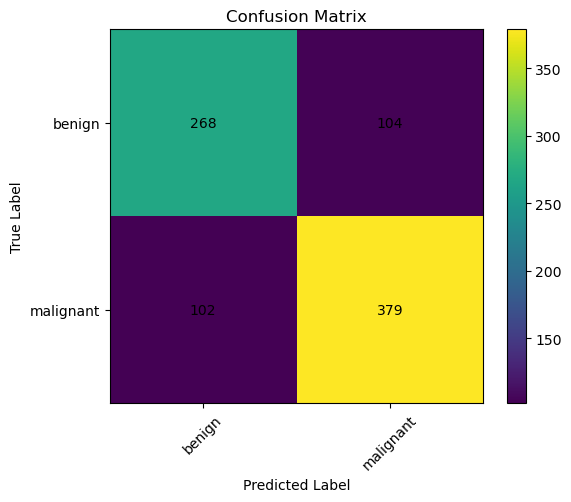

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

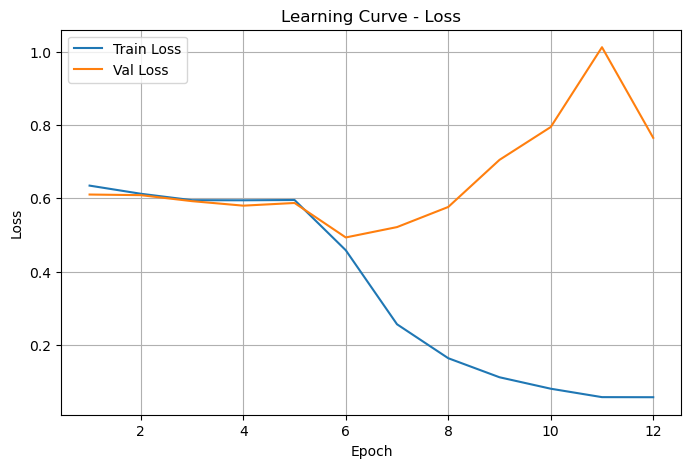

In [20]:
epochs_ran = range(1, len(history["epoch"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid(True)
plt.show()

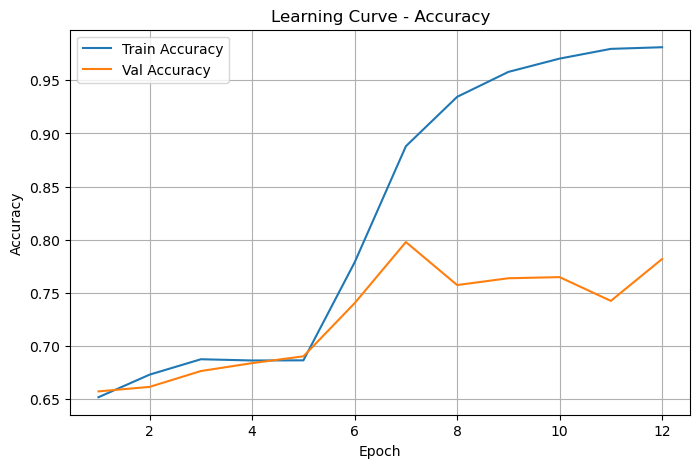

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

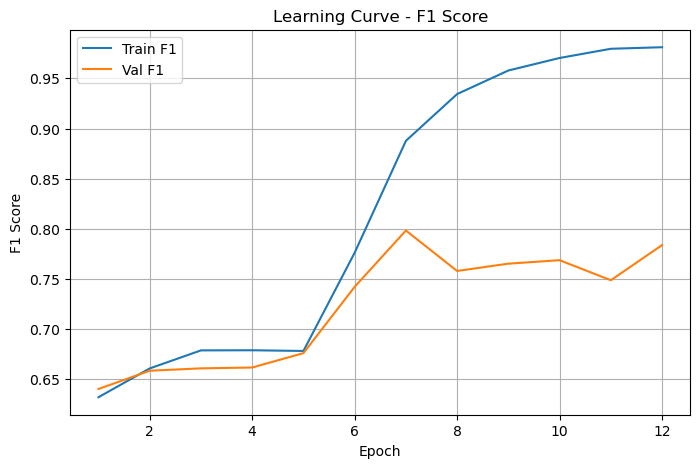

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_f1"], label="Train F1")
plt.plot(epochs_ran, history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Learning Curve - F1 Score")
plt.legend()
plt.grid(True)
plt.show()

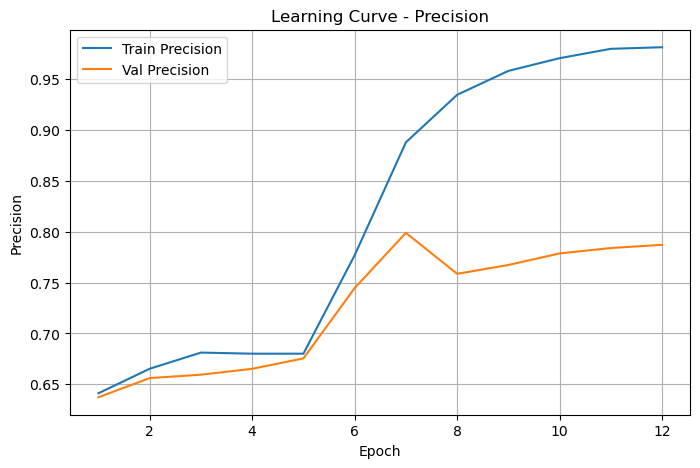

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_precision"], label="Train Precision")
plt.plot(epochs_ran, history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Learning Curve - Precision")
plt.legend()
plt.grid(True)
plt.show()

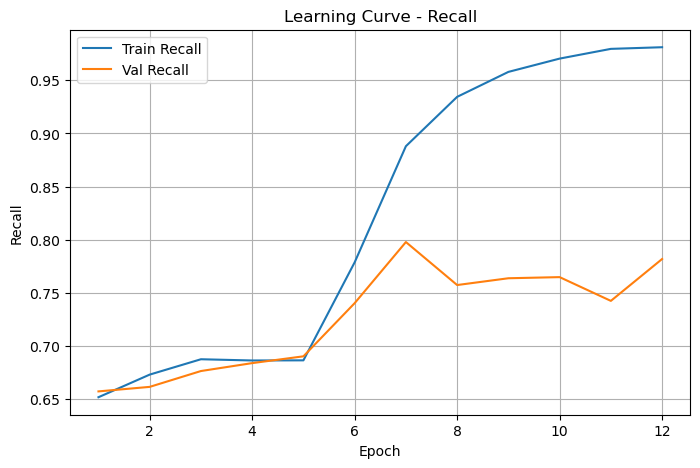

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_recall"], label="Train Recall")
plt.plot(epochs_ran, history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Learning Curve - Recall")
plt.legend()
plt.grid(True)
plt.show()

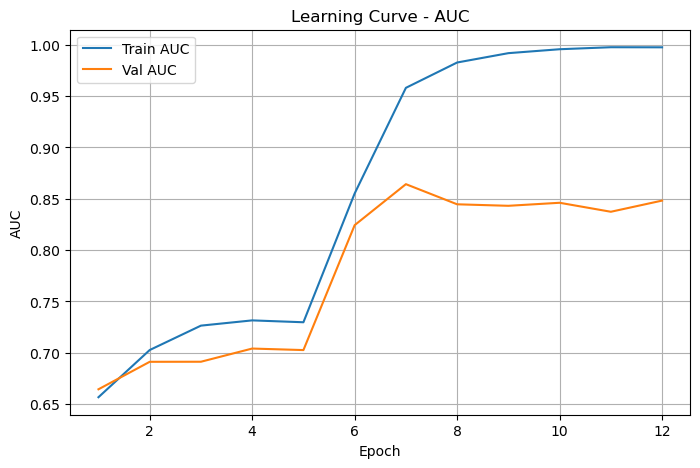

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_auc"], label="Train AUC")
plt.plot(epochs_ran, history["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Learning Curve - AUC")
plt.legend()
plt.grid(True)
plt.show()

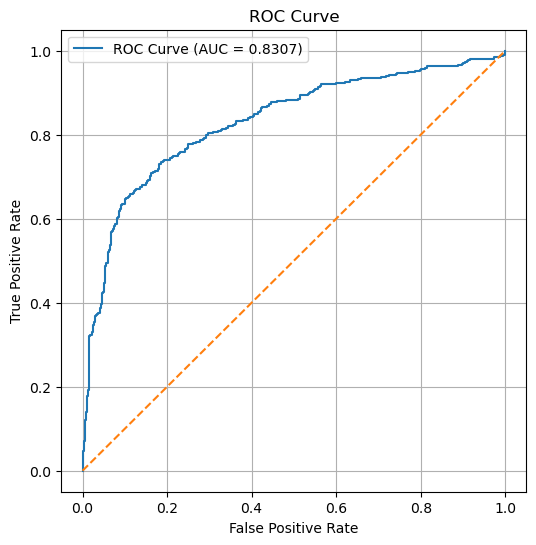

In [26]:
if num_classes == 2:
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_metrics['auc']:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("ROC curve cell is set for binary classification only.")

In [27]:
torch.save(model.state_dict(), "saved_models/resnet50_best_auc.pth")
print("Model saved")

Model saved


In [28]:
loaded_model = models.resnet50(weights=None)
loaded_model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(loaded_model.fc.in_features, num_classes)
)

loaded_model.load_state_dict(torch.load("saved_models/resnet50_best_auc.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

print("Model loaded successfully")

C:\Users\rgzep\AppData\Local\Temp\ipykernel_10252\4011774236.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("saved_models/resnet

Model loaded successfully
